In [2]:
import h5py
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import pandas as pd
from tqdm import tqdm
import astropy.units as u

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'font.size': 20,         #tamaño de fuente general
    'axes.titlesize': 20,    #tamaño de fuente para títulos de ejes
    'axes.labelsize': 20,    #tamaño de fuente para etiquetas de ejes
    'xtick.labelsize': 20,   #tamaño de fuente para etiquetas del eje x
    'ytick.labelsize': 20,   #tamaño de fuente para etiquetas del eje y
    'legend.fontsize': 20,   #tamaño de fuente para la leyenda
    'figure.titlesize': 20   #tamaño de fuente para el título de la figura
})

plt.style.use(['science', 'grid'])

In [3]:
df_colmagdata_obsgals = pd.read_csv('colmagdata_obsgals.csv', delimiter = ',', header = 0, names=['gapp', 'rapp', 'newrabs'])
gapp = np.asarray(df_colmagdata_obsgals['gapp'])
rapp = np.asarray(df_colmagdata_obsgals['rapp'])
newrabs = np.asarray(df_colmagdata_obsgals['newrabs'])
print(df_colmagdata_obsgals)

            gapp       rapp    newrabs
0      18.189713  17.202885 -20.826262
1      19.296179  17.800484 -21.674958
2      19.027917  17.803170 -21.355379
3      19.822431  18.162898 -22.577430
4      19.514741  19.145973 -18.902168
...          ...        ...        ...
49995  17.063400  16.155642 -22.120245
49996  16.960592  16.503698 -18.763852
49997  18.467763  17.474081 -20.809193
49998  19.918337  18.304759 -22.459208
49999  17.418392  16.960501 -19.677822

[50000 rows x 3 columns]


In [4]:
#(Bruzual & Charlot+2016)
df_singleburst = pd.read_csv('singleburst.csv', delimiter = ',', header = 0, names = ['t[yr]', 'M_FUV', 'M_NUV', 'M_u', 'M_g', 'M_r'])
t_yr = np.asarray(df_singleburst['t[yr]'])
M_FUV = np.asarray(df_singleburst['M_FUV'])
M_NUV = np.asarray(df_singleburst['M_NUV'])
M_u = np.asarray(df_singleburst['M_u'])
M_g = np.asarray(df_singleburst['M_g'])
M_r = np.asarray(df_singleburst['M_r'])
#Luminosity
L_g = 10**(-M_g/2.5)
L_r = 10**(-M_r/2.5)
print(df_singleburst)

               t[yr]      M_FUV      M_NUV        M_u       M_g       M_r
0       0.000000e+00  -0.855100  -0.459600   0.218100  0.617000  1.106600
1       1.000000e+05  -0.855100  -0.459600   0.218100  0.617000  1.106600
2       2.000000e+05  -0.855100  -0.459600   0.218100  0.617000  1.106600
3       3.000000e+05  -0.855100  -0.459600   0.218100  0.617000  1.106600
4       4.000000e+05  -0.855100  -0.459600   0.218100  0.617000  1.106600
...              ...        ...        ...        ...       ...       ...
199996  1.999960e+10  13.824986  13.536676  10.019875  8.071281  7.197982
199997  1.999970e+10  13.824989  13.536682  10.019881  8.071286  7.197986
199998  1.999980e+10  13.824992  13.536688  10.019887  8.071290  7.197991
199999  1.999990e+10  13.824996  13.536693  10.019893  8.071295  7.197995
200000  2.000000e+10  13.824999  13.536699  10.019899  8.071300  7.197999

[200001 rows x 6 columns]


In [5]:
#pregunta 4
t_end = 14*10**3 #Myr
dt = 1 #Myr
n_steps = int(t_end/dt) 
jump = int(dt/0.1)
print(jump)
print(n_steps)

10
14000


In [6]:
t_arr = []
for i in tqdm(range(0, n_steps), 'Procesando: '):
    t_now = i*dt
    t_arr.append(t_now)
t_arr = np.asarray(t_arr)
print(t_arr)

Procesando: 100%|█████████████████████| 14000/14000 [00:00<00:00, 513405.63it/s]

[    0     1     2 ... 13997 13998 13999]


In [7]:
#for low mass galaxy
galaxy_mass = 1*10**9 #Msun

t_in_fall = 5000 #Myr
t_no_gas = 1390 #Myr
t_tot = t_end - t_in_fall + t_no_gas

sfr_lower_gal_value = ((galaxy_mass/t_tot)* (u.Msun/u.Myr)).to('Msun/yr').value #M_sun/yr

sfr = np.zeros(n_steps) #Msun/yr
sfr[np.where(t_arr <= t_tot)[0]] = sfr_lower_gal_value * (dt*10**6)

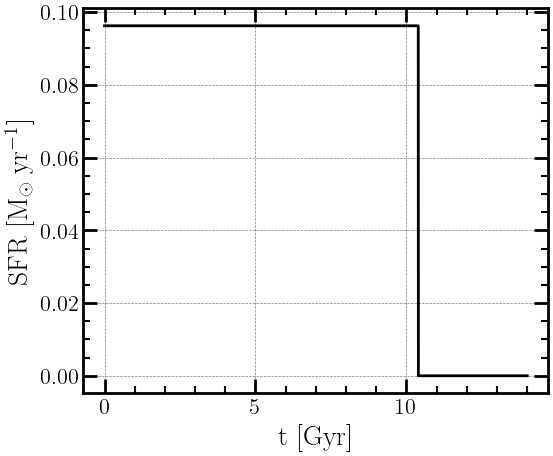

In [52]:
#plot del color
fig = plt.figure(figsize = (6,5))
gs = fig.add_gridspec()
ax = gs.subplots()

for i in range(0, 2):
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(axis='both', which='major', labelsize=16, length=10, width=2)
    ax.tick_params(axis='both', which='minor', length=5, width=1.5)
    ax.minorticks_on()
    
ax.plot(t_arr/10**3, sfr/(dt*10**6), color = 'black', lw = 2)

ax.set_xlabel('t [Gyr]')
ax.set_ylabel(r'SFR [M$_{\odot}$ yr$^{-1}$]')

plt.show()

In [9]:
m_g_arr = []
m_r_arr = []

for i in tqdm(range(0, n_steps), 'Procesando: '):
    t_now = i*dt
    k = i + 1
    l_g, l_r = 0, 0
    for j in range(0, i):
        k = k - 1
        l_g = l_g + sfr[j]*dt*L_g[k*jump]
        l_r = l_r + sfr[j]*dt*L_r[k*jump]
    m_g = -2.5 * np.log10(l_g)
    m_r = -2.5 * np.log10(l_r)
    m_g_arr.append(m_g)
    m_r_arr.append(m_r)

print(f'm_r = {m_r}')
print('----------------------------')
print(f'm_g - m_r = {m_g-m_r}')
print('----------------------------')
print(f't_now = {t_now} [Myr]')

Procesando:   0%|                                     | 0/14000 [00:00<?, ?it/s]/tmp/ipykernel_21798/2336396034.py:12: RuntimeWarning: divide by zero encountered in log10
  m_g = -2.5 * np.log10(l_g)
/tmp/ipykernel_21798/2336396034.py:13: RuntimeWarning: divide by zero encountered in log10
  m_r = -2.5 * np.log10(l_r)
Procesando: 100%|█████████████████████████| 14000/14000 [03:12<00:00, 72.91it/s]

m_g = -16.18723063807421
----------------------------
m_g - m_r = 0.7817894986718539
----------------------------
t_now = 13999 [Myr]


In [11]:
m_g_arr = np.asarray(m_g_arr)
m_r_arr = np.asarray(m_r_arr)
g_r_arr = m_g_arr-m_r_arr

/tmp/ipykernel_21798/2324597669.py:3: RuntimeWarning: invalid value encountered in subtract
  g_r_arr = m_g_arr-m_r_arr


In [16]:
from scipy.stats import gaussian_kde

x = newrabs
y = gapp-rapp
mask = np.isfinite(x) & np.isfinite(y)
x_clean = x[mask]
y_clean = y[mask]

xy = np.vstack([x_clean, y_clean])
z = gaussian_kde(xy)(xy)

idx = z.argsort()
x_sorted = x_clean[idx]
y_sorted = y_clean[idx]
z_sorted = z[idx]

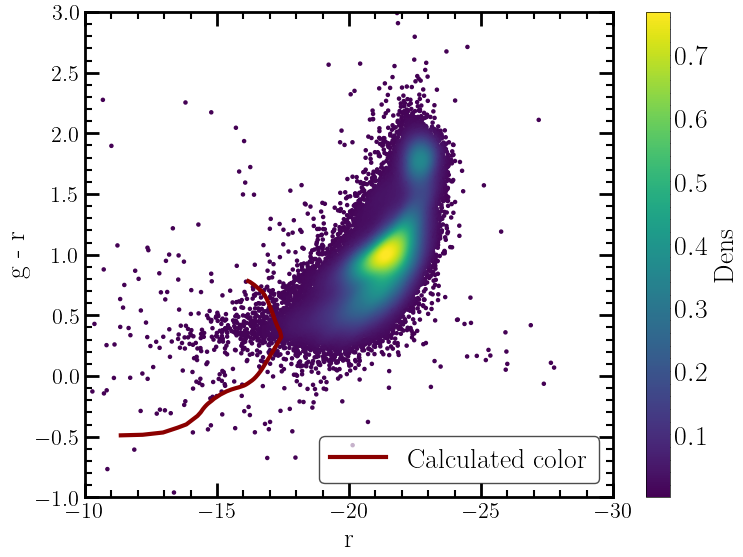

In [51]:
fig = plt.figure(figsize = (8,6))
ax = fig.subplots()

for i in range(0, 2):
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(axis='both', which='major', labelsize=16, length=10, width=2)
    ax.tick_params(axis='both', which='minor', length=5, width=1.5)
    ax.minorticks_on()

ax.plot(m_r_arr, g_r_arr, color = 'darkred', lw = 3, label = 'Calculated color')
sc = plt.scatter(x_sorted, y_sorted, c=z_sorted, s=5, cmap='viridis')
fig.colorbar(sc, label='Dens')
ax.set_xlabel('r')
ax.set_ylabel('g - r')
fig.tight_layout()
ax.set_ylim(-1, 3)
ax.set_xlim(-10, -30)
ax.grid(False)
ax.legend(edgecolor = 'black', framealpha = 0.7)
plt.show()